In [ ]:
%pip install -U "qiskit>=2.2" qiskit-ibm-runtime qiskit-aer pylatexenc matplotlib

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler import generate_preset_pass_manager

In [ ]:
QiskitRuntimeService.save_account(
    channel        = 'ibm_quantum_platform',
    token          = 'YOUR_API_KEY',
    instance       = 'YOUR_CRN',
    set_as_default = True,
    overwrite      = True,
)

In [39]:
qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

qc.measure_all()

service = QiskitRuntimeService()

backend = service.least_busy(
    simulator      = False,
    operational    = True,
    min_num_qubits = 2,
)

print(f'Backend: {backend.name}')

pm = generate_preset_pass_manager(
    backend            = backend,
    optimization_level = 1,
)

isa_qc = pm.run(qc)
sampler = Sampler(mode = backend)
job = sampler.run([isa_qc], shots = 1000)

print(f'Job ID:  {job.job_id()}')

result = job.result()[0]
counts = result.data.meas.get_counts()

Backend: ibm_kingston
Job ID:  d8653t5g7okc73eklp30


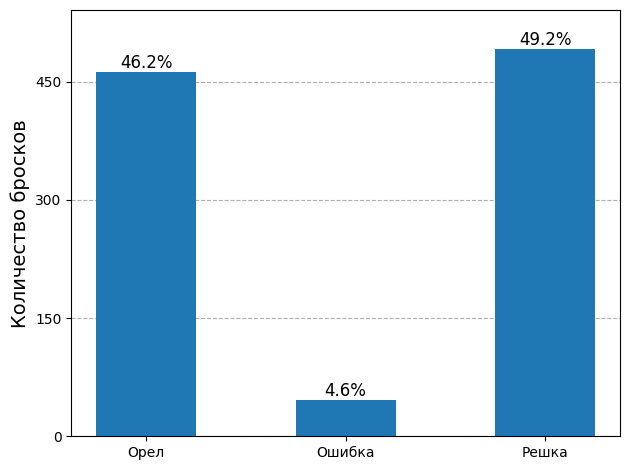

In [41]:
pretty_counts = {
    'Орел'   : counts.get('00', 0),
    'Ошибка' : counts.get('01', 0) + counts.get('10', 0),
    'Решка'  : counts.get('11', 0),
}
total = sum(pretty_counts.values())

fig = plot_histogram(
    pretty_counts,
    # figsize  = (16, 9),
    bar_labels = False, 
)
ax = fig.axes[0]
ax.set_ylabel('Количество бросков')

for label in ax.get_xticklabels():
    label.set_rotation(0)
    label.set_horizontalalignment("center")

for bar in ax.patches:
    height = bar.get_height()
    percent = height / total * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{percent:.1f}%',
        ha       = 'center',
        va       = 'bottom',
        fontsize = 12,
    )

ax.set_ylim(0, max(pretty_counts.values()) * 1.1)

fig.tight_layout()
fig